In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [2]:
class QuadraticState(TypedDict):
    a: int
    b: int
    c: int
    eqn: str
    discrimant: float
    res: str

In [3]:
def show_eqn(state: QuadraticState)-> QuadraticState:
    eqn = f"{state['a']}X2{state['b']}+{state['c']}"
    return {'eqn':eqn}

def cal_discrimant(state: QuadraticState) -> QuadraticState:
    dist = state['b']**2 - (4*state['a']*state['c'])
    return {'discrimant':dist}

def real_roots(state: QuadraticState)-> QuadraticState:
    root1 = (-state['b'] + state['discrimant']**0.5)/(2*state['a'])
    root2 = (-state['b'] - state['discrimant']**0.5)/(2*state['a'])
    res = f"roots are {root1} and {root2}"
    return {'res': res}

def repeat_roots(state: QuadraticState)-> QuadraticState:
    root1 = (-state['b'])/(2*state['a'])
    res = f"roots are repeating: {root1}"
    return {'res': res}

def no_roots(state: QuadraticState)-> QuadraticState:

    res = f"no real roots"
    return {'res': res}

def check_condition(state: QuadraticState)-> Literal['real_roots','repeat_roots','no_roots']:
    if state['discrimant']>0:
        return 'real_roots'
    elif state['discrimant']==0:
        return 'repeat_roots'
    else:
        return 'no_roots'

In [4]:
graph = StateGraph(QuadraticState)

graph.add_node('show_eqn', show_eqn)
graph.add_node('cal_discrimant',cal_discrimant)
graph.add_node('real_roots',real_roots)
graph.add_node('repeat_roots',repeat_roots)
graph.add_node('no_roots',no_roots)

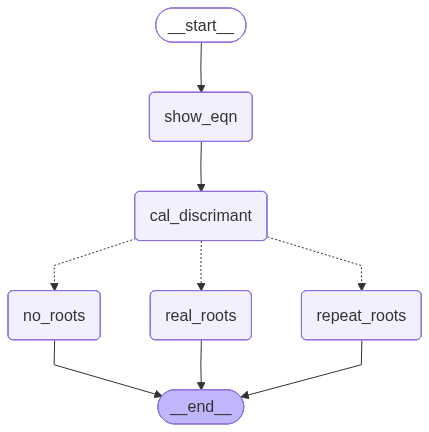

In [5]:
graph.add_edge(START, 'show_eqn')
graph.add_edge('show_eqn','cal_discrimant')

graph.add_conditional_edges('cal_discrimant',check_condition)
graph.add_edge('real_roots',END)
graph.add_edge('repeat_roots',END)
graph.add_edge('no_roots',END)
wfs = graph.compile()
wfs


In [6]:
init = {'a':4, 'b':-5,'c':2}
final = wfs.invoke(init)
final

{'a': 4,
 'b': -5,
 'c': 2,
 'eqn': '4X2-5+2',
 'discrimant': -7,
 'res': 'no real roots'}

In [7]:
init = {'a':4, 'b':-5,'c':-4}
final = wfs.invoke(init)
final

{'a': 4,
 'b': -5,
 'c': -4,
 'eqn': '4X2-5+-4',
 'discrimant': 89,
 'res': 'roots are 1.8042476415070754 and -0.5542476415070754'}

In [9]:
init = {'a':4, 'b':2,'c':1
        }
final = wfs.invoke(init)
final

{'a': 4,
 'b': 2,
 'c': 1,
 'eqn': '4X22+1',
 'discrimant': -12,
 'res': 'no real roots'}